# E3 - regularization ablation

Dropout, L2 (weight decay), and normalization, tested one at a time against the full baseline (all three together). Architecture and optimizer are unchanged from E1/E2 - block2 stays depthwise-separable, block3 stays dilated, optimizer stays Adam. Only the regularization/normalization settings change here.

In [1]:
import os

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from citrus_common import CitrusLeafDataset, get_transforms, load_normalization_stats
from citrus_model import CitrusNetRegNormAblation, init_weights
from citrus_train import set_seed, fit

os.makedirs("checkpoints", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
mean, std = load_normalization_stats("normalization_stats.json")

train_transform = get_transforms(augment=True, mean=mean, std=std, size=224)
val_transform = get_transforms(augment=False, mean=mean, std=std, size=224)

train_ds = CitrusLeafDataset("processed/224", "train", transform=train_transform)
val_ds = CitrusLeafDataset("processed/224", "val", transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

len(train_ds), len(val_ds)

(1131, 242)

In [3]:
# order matches class_to_idx from the sorted folder names: aphids, gummosis, healthy, leaf_minnor
class_weights = torch.tensor([0.9921, 0.9240, 1.1880, 0.9363], dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

## Configs

`reg_full` (dropout 0.5 + batchnorm + weight_decay 1e-4) is the existing baseline run from Section V - reused here, not retrained. The three new configs each isolate a single regularizer, with the others stripped out entirely.

In [4]:
config_params = {
    "reg_none":         {"dropout_p": 0.0, "normalization_type": "none", "weight_decay": 0.0},
    "reg_dropout_only": {"dropout_p": 0.5, "normalization_type": "none", "weight_decay": 0.0},
    "reg_l2_only":      {"dropout_p": 0.0, "normalization_type": "none", "weight_decay": 1e-4},
    "reg_full":         {"dropout_p": 0.5, "normalization_type": "batchnorm", "weight_decay": 1e-4},
}

new_configs = ["reg_none", "reg_dropout_only", "reg_l2_only"]

In [5]:
def history_to_df(history):
    return pd.DataFrame({
        "epoch": range(1, len(history["train_loss"]) + 1),
        "train_loss": history["train_loss"],
        "train_acc": history["train_acc"],
        "val_loss": history["val_loss"],
        "val_acc": history["val_acc"],
        "lr": history["lr"],
    })

In [6]:
results = {}
param_counts = {}

for name in new_configs:
    cfg = config_params[name]
    print(f"--- training {name} ---")

    set_seed(42)
    model = CitrusNetRegNormAblation(
        num_classes=4,
        dropout_p=cfg["dropout_p"],
        normalization_type=cfg["normalization_type"],
    )
    init_weights(model)
    model = model.to(device)

    n_params = sum(p.numel() for p in model.parameters())
    param_counts[name] = n_params
    print(f"{name}: {n_params} parameters")

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    history = fit(
        model, train_loader, val_loader, criterion, optimizer, device,
        max_epochs=100, early_stop_patience=10, scheduler=scheduler,
        checkpoint_path=f"checkpoints/reg_{name}_best.pt",
    )

    df = history_to_df(history)
    df.to_csv(f"history_reg_{name}.csv", index=False)
    results[name] = df

--- training reg_none ---
reg_none: 415012 parameters
epoch   1  train_loss 1.6693  train_acc 0.3121  val_loss 1.2312  val_acc 0.5083  lr 1.00e-03
epoch   2  train_loss 1.1108  train_acc 0.4960  val_loss 0.8706  val_acc 0.6281  lr 1.00e-03
epoch   3  train_loss 0.7868  train_acc 0.6543  val_loss 0.4483  val_acc 0.7934  lr 1.00e-03
epoch   4  train_loss 0.6000  train_acc 0.7365  val_loss 0.5301  val_acc 0.7107  lr 1.00e-03
epoch   5  train_loss 0.4700  train_acc 0.8143  val_loss 0.1983  val_acc 0.9421  lr 1.00e-03
epoch   6  train_loss 0.2880  train_acc 0.8912  val_loss 0.5268  val_acc 0.7893  lr 1.00e-03
epoch   7  train_loss 0.2746  train_acc 0.9116  val_loss 0.1113  val_acc 0.9504  lr 1.00e-03
epoch   8  train_loss 0.2239  train_acc 0.9240  val_loss 0.1582  val_acc 0.9298  lr 1.00e-03
epoch   9  train_loss 0.3480  train_acc 0.8736  val_loss 0.2203  val_acc 0.9132  lr 1.00e-03
epoch  10  train_loss 0.2213  train_acc 0.9222  val_loss 0.1917  val_acc 0.9132  lr 1.00e-03
epoch  11  train

In [7]:
# reg_full already trained in Section V - load it instead of retraining
baseline_df = pd.read_csv("history_baseline.csv")
results["reg_full"] = baseline_df
param_counts["reg_full"] = 416036

In [8]:
def summarize(name, df):
    best_idx = df["val_loss"].idxmin()
    best_epoch = int(df.loc[best_idx, "epoch"])
    best_val_loss = float(df.loc[best_idx, "val_loss"])
    best_val_acc = float(df.loc[best_idx, "val_acc"])

    reached_99 = df[df["val_acc"] >= 0.99]
    epochs_to_99 = int(reached_99["epoch"].iloc[0]) if len(reached_99) > 0 else "never"

    cfg = config_params[name]
    return {
        "config": name,
        "dropout_p": cfg["dropout_p"],
        "normalization_type": cfg["normalization_type"],
        "weight_decay": cfg["weight_decay"],
        "param_count": param_counts[name],
        "epochs_run": int(df["epoch"].max()),
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
        "epochs_to_reach_99pct": epochs_to_99,
    }

order = ["reg_none", "reg_dropout_only", "reg_l2_only", "reg_full"]
summary_df = pd.DataFrame([summarize(name, results[name]) for name in order])
print(summary_df.to_string(index=False))
summary_df

          config  dropout_p normalization_type  weight_decay  param_count  epochs_run  best_epoch  best_val_loss  best_val_acc  epochs_to_reach_99pct
        reg_none        0.0               none        0.0000       415012          42          32       0.000623           1.0                     13
reg_dropout_only        0.5               none        0.0000       415012          57          47       0.000624           1.0                     21
     reg_l2_only        0.0               none        0.0001       415012          55          45       0.000683           1.0                     13
        reg_full        0.5          batchnorm        0.0001       416036          40          30       0.001026           1.0                      4


,config,dropout_p,normalization_type,weight_decay,param_count,epochs_run,best_epoch,best_val_loss,best_val_acc,epochs_to_reach_99pct
0,reg_none,0.0,none,0.0000,415012,42,32,0.000623,1.0,13
1,reg_dropout_only,0.5,none,0.0000,415012,57,47,0.000624,1.0,21
2,reg_l2_only,0.0,none,0.0001,415012,55,45,0.000683,1.0,13
3,reg_full,0.5,batchnorm,0.0001,416036,40,30,0.001026,1.0,4


## Plots

Both figures overlay all four configs. Val_loss is on a log scale, since accuracy alone is near ceiling for all of them and hides most of the differences that actually matter here.

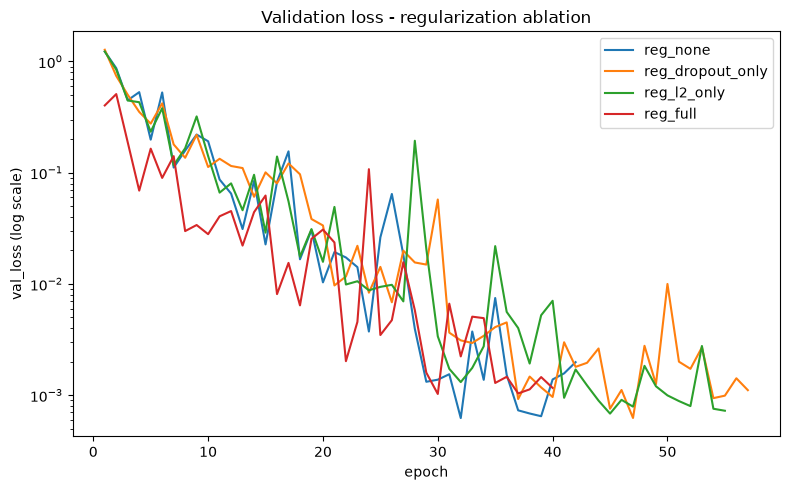

In [9]:
plt.figure(figsize=(8, 5))
for name in order:
    df = results[name]
    plt.plot(df["epoch"], df["val_loss"], label=name)
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("val_loss (log scale)")
plt.title("Validation loss - regularization ablation")
plt.legend()
plt.tight_layout()
plt.show()

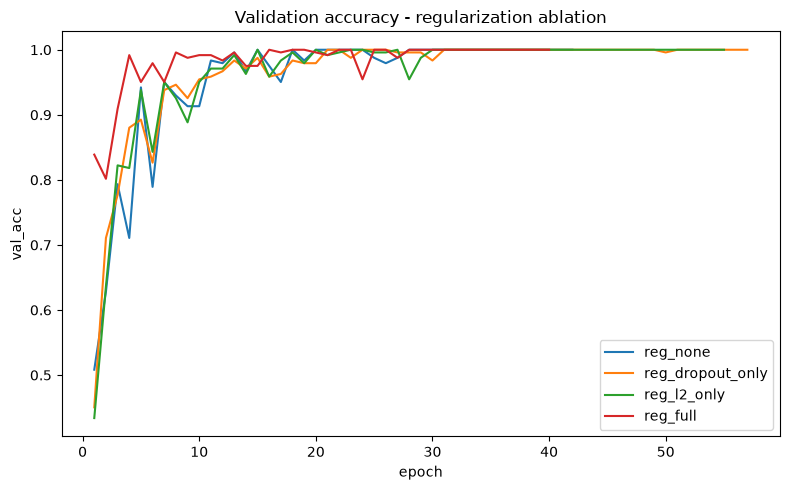

In [10]:
plt.figure(figsize=(8, 5))
for name in order:
    df = results[name]
    plt.plot(df["epoch"], df["val_acc"], label=name)
plt.xlabel("epoch")
plt.ylabel("val_acc")
plt.title("Validation accuracy - regularization ablation")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
numeric_99 = summary_df[summary_df["epochs_to_reach_99pct"].apply(lambda x: isinstance(x, (int, float)))]
fastest_row = numeric_99.sort_values("epochs_to_reach_99pct").iloc[0]

lowest_loss_row = summary_df.loc[summary_df["best_val_loss"].idxmin()]

reg_none_df = results["reg_none"]
final_train_acc = reg_none_df["train_acc"].iloc[-1]
final_val_acc = reg_none_df["val_acc"].iloc[-1]
gap = final_train_acc - final_val_acc

print(f"fastest to reach 99% val_acc: {fastest_row['config']} (epoch {fastest_row['epochs_to_reach_99pct']})")
print(f"lowest best_val_loss: {lowest_loss_row['config']} ({lowest_loss_row['best_val_loss']:.5f})")
print(f"reg_none final train_acc {final_train_acc:.4f} vs final val_acc {final_val_acc:.4f}, gap {gap:.4f}")
if gap > 0.02:
    print("gap of this size suggests some overfitting once all regularization is removed")
else:
    print("gap is small - no real sign of overfitting even with no regularization at all")

fastest to reach 99% val_acc: reg_full (epoch 4)
lowest best_val_loss: reg_none (0.00062)
reg_none final train_acc 0.9991 vs final val_acc 1.0000, gap -0.0009
gap is small - no real sign of overfitting even with no regularization at all
